# 2. Синхронизация и межканальная зависимость

**Цели:** оценить зависимость каналов друг от друга и то, как она меняется во времени. Это диагностика возможной синхронизации, не доказательство конкретного механизма связи.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_synchronized_series.csv").exists())
DATA = ROOT / "data/generated/kuramoto_synchronized_series.csv"
SEED = 42
df = pd.read_csv(DATA)
channel_names = [column for column in df.columns if column.startswith("channel_")]
x = df[channel_names].to_numpy()
assert np.isfinite(x).all() and x.ndim == 2

,channel_00,channel_01,channel_02,channel_03,channel_04,channel_05,channel_06,channel_07,channel_08,channel_09,channel_10,channel_11
channel_00,1.00,0.96,1.00,0.98,0.93,0.97,1.00,0.99,0.92,0.94,0.93,0.98
channel_01,0.96,1.00,0.96,0.97,0.90,0.95,0.96,0.96,0.89,0.99,0.99,0.95
channel_02,1.00,0.96,1.00,0.98,0.95,0.99,1.00,1.00,0.94,0.95,0.94,1.00
channel_03,0.98,0.97,0.98,1.00,0.90,0.96,0.99,1.00,0.88,0.97,0.93,0.97
channel_04,0.93,0.90,0.95,0.90,1.00,0.98,0.92,0.93,1.00,0.89,0.91,0.97
channel_05,0.97,0.95,0.99,0.96,0.98,1.00,0.97,0.98,0.98,0.95,0.94,1.00
channel_06,1.00,0.96,1.00,0.99,0.92,0.97,1.00,1.00,0.91,0.95,0.93,0.99
channel_07,0.99,0.96,1.00,1.00,0.93,0.98,1.00,1.00,0.91,0.96,0.93,0.99
channel_08,0.92,0.89,0.94,0.88,1.00,0.98,0.91,0.91,1.00,0.88,0.90,0.96
channel_09,0.94,0.99,0.95,0.97,0.89,0.95,0.95,0.96,0.88,1.00,0.99,0.95


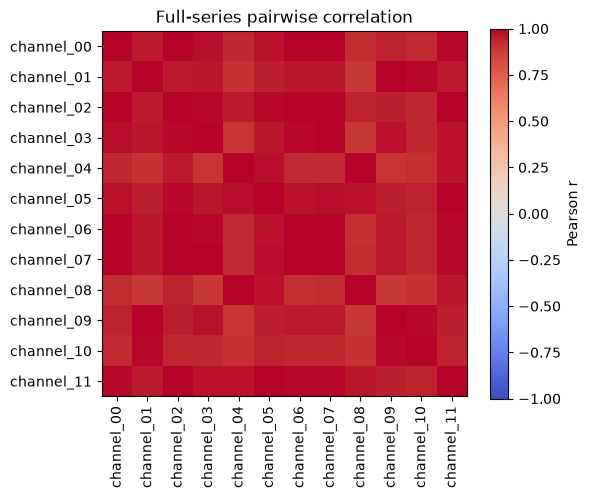

In [2]:
import matplotlib.pyplot as plt
correlation = pd.DataFrame(x, columns=channel_names).corr()
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set(xticks=range(len(channel_names)), xticklabels=channel_names,
       yticks=range(len(channel_names)), yticklabels=channel_names,
       title="Full-series pairwise correlation")
ax.tick_params(axis="x", rotation=90)
fig.colorbar(image, ax=ax, label="Pearson r")
fig.tight_layout()
correlation.round(2)

{'first_window_mean_abs_corr': 0.7586206340351013,
 'last_window_mean_abs_corr': 0.999096408424987}

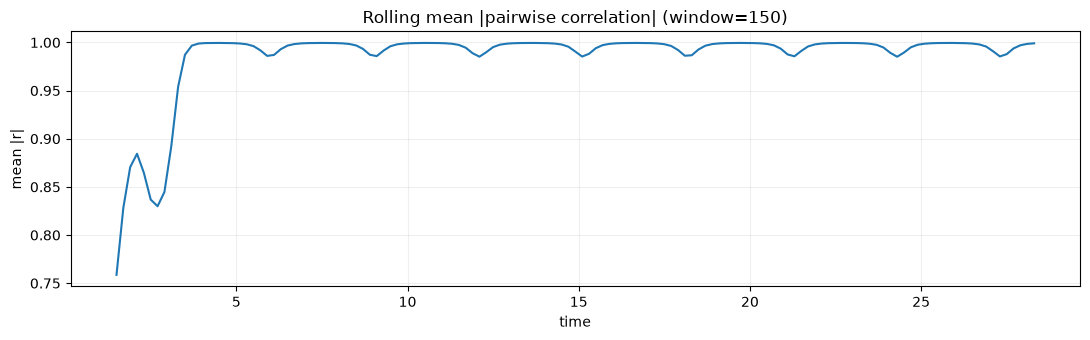

In [3]:
window = 150
step = 10
starts = np.arange(0, len(x) - window, step)
mean_abs_corr = []
for start in starts:
    segment = x[start:start + window]
    corr = np.corrcoef(segment, rowvar=False)
    off_diagonal = corr[~np.eye(len(channel_names), dtype=bool)]
    mean_abs_corr.append(np.mean(np.abs(off_diagonal)))
mean_abs_corr = np.array(mean_abs_corr)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df["timestamp"].to_numpy()[starts + window // 2], mean_abs_corr)
ax.set(title=f"Rolling mean |pairwise correlation| (window={window})", xlabel="time", ylabel="mean |r|")
ax.grid(alpha=.2); fig.tight_layout()
{"first_window_mean_abs_corr": float(mean_abs_corr[0]), "last_window_mean_abs_corr": float(mean_abs_corr[-1])}

Рост усреднённой корреляции согласуется с усилением синхронизации, но окно, шаг и число каналов влияют на оценку.

**Самопроверка:** как выбор окна меняет вывод? Почему средняя |корреляция| не отличает истинную фазовую синхронизацию от общего тренда? Какой канал стоит проверить отдельно, если он ведёт себя иначе остальных?